# Session 1b: fMRI Quality Control and Preprocessing

In [sess-1a](sess-1a.ipynb) we learned how raw scanner data are converted to NIfTI and organised into a **BIDS** dataset. We also saw that a BIDS-compliant dataset unlocks a whole ecosystem of **BIDS Apps**: container-packaged pipelines that take a BIDS folder as input and produce standardised derivatives as output.

This session puts two of those BIDS Apps to work:

  1. **MRIQC**, to assess the **quality** of the raw data *before* any processing.

  2. **fMRIprep**, to **preprocess** the fMRI data, and to re-assess quality *after* preprocessing using its HTML report.

The lesson is organised around **two main themes**:

  1. **Quality Control** of raw BIDS data with MRIQC

  2. **Preprocessing** of fMRI data with fMRIprep

> 💡 **About running MRIQC and fMRIprep.** Both tools are *heavy*: fMRIprep typically runs for several hours per subject and uses a lot of RAM and disk. For that reason, **we will not run either in class**. Instead we look at pre-computed outputs that the OpenNeuro community publishes alongside the raw data. At the end of the notebook you will run fMRIprep yourself at home on a single subject, as an exercise.

Icons used throughout, identical to sess-1a:

| Icon | Meaning |
|---|---|
| 🖥️ | **Switch to Neurodesktop**: you will need to open the Neurodesktop environment for this section |
| 🐍 | **Python**: this section contains code cells to run in the notebook |
| 📝 | **Practice**: exercises and tasks for you to complete |


## 1. The dataset

For this session we use **[ds000117](https://openneuro.org/datasets/ds000117)**, a BIDS dataset by Wakeman & Henson (2015). Sixteen adults viewed images of **famous faces**, **unfamiliar faces**, and **scrambled faces** while being scanned: an event-related fMRI design with 9 runs per subject. It is a canonical dataset for teaching first-level GLM analysis, which we will come back to in the next session.

For our purposes today, the key point is that ds000117 also has **pre-computed MRIQC and fMRIprep derivatives** published by the [OpenNeuroDerivatives](https://github.com/OpenNeuroDerivatives) community. We do not need to run either pipeline ourselves: we just inspect their outputs.

### 1.1 🐍 Get the raw BIDS data

The raw dataset and its derivatives are pre-staged for you on the shared course storage at `/data/shared/sess-1b/`. In this first section we copy **only the raw BIDS folder** into your personal `results/sess-1b/` directory. We will come back for the derivatives later, when we need them.


In [ ]:
! pip install nilearn pybids

In [ ]:
from pathlib import Path

# Every path we build below is anchored at results/sess-1b/ inside your personal
# HBI folder. Python's pathlib.Path joins folder names with '/', e.g.
# RESULTS / 'ds000117' -> Path('results/sess-1b/ds000117').
RESULTS = Path('results/sess-1b')
RESULTS.mkdir(parents=True, exist_ok=True)   # create the folder if it does not exist yet

# Three folders we will fill as the notebook progresses:
#   ds000117          raw BIDS dataset (this section)
#   ds000117-mriqc    MRIQC outputs    (Section 2)
#   ds000117-fmriprep fMRIprep outputs (Section 3)
RAW_DIR      = RESULTS / 'ds000117'
MRIQC_DIR    = RESULTS / 'ds000117-mriqc'
FMRIPREP_DIR = RESULTS / 'ds000117-fmriprep'

In [4]:
# Recursive copy of the raw BIDS dataset from the shared course folder to your own.
# The shared source is read-only, so we wipe the target first to make the cell
# idempotent (running it a second time will not fail on read-only overwrite).
# Takes a few seconds on a local filesystem.

# FIXME: this throws a bunch of permission errors. perhaps folder were created with wrong permissions?

! rm -rf /home/jovyan/HBI/results/sess-1b/ds000117
! cp -r /data/shared/sess-1b/ds000117 /home/jovyan/HBI/results/sess-1b/


rm: cannot remove '/home/jovyan/HBI/results/sess-1b/ds000117/run-1_echo-2_FLASH.json': Permission denied
rm: cannot remove '/home/jovyan/HBI/results/sess-1b/ds000117/run-2_echo-5_FLASH.json': Permission denied
rm: cannot remove '/home/jovyan/HBI/results/sess-1b/ds000117/task-facerecognition_events.json': Permission denied
rm: cannot remove '/home/jovyan/HBI/results/sess-1b/ds000117/run-2_echo-4_FLASH.json': Permission denied
rm: cannot remove '/home/jovyan/HBI/results/sess-1b/ds000117/participants.tsv': Permission denied
rm: cannot remove '/home/jovyan/HBI/results/sess-1b/ds000117/run-1_echo-7_FLASH.json': Permission denied
rm: cannot remove '/home/jovyan/HBI/results/sess-1b/ds000117/sub-03/ses-mri/anat/sub-03_ses-mri_run-1_echo-7_FLASH.nii.gz': Permission denied
rm: cannot remove '/home/jovyan/HBI/results/sess-1b/ds000117/sub-03/ses-mri/anat/sub-03_ses-mri_run-1_echo-4_FLASH.nii.gz': Permission denied
rm: cannot remove '/home/jovyan/HBI/results/sess-1b/ds000117/sub-03/ses-mri/anat/sub

cp: cannot create regular file '/home/jovyan/HBI/results/sess-1b/ds000117/dataset_description.json': Permission denied
cp: cannot create regular file '/home/jovyan/HBI/results/sess-1b/ds000117/participants.json': Permission denied
cp: cannot create regular file '/home/jovyan/HBI/results/sess-1b/ds000117/participants.tsv': Permission denied
cp: cannot create regular file '/home/jovyan/HBI/results/sess-1b/ds000117/run-1_echo-1_FLASH.json': Permission denied
cp: cannot create regular file '/home/jovyan/HBI/results/sess-1b/ds000117/run-1_echo-2_FLASH.json': Permission denied
cp: cannot create regular file '/home/jovyan/HBI/results/sess-1b/ds000117/run-1_echo-3_FLASH.json': Permission denied
cp: cannot create regular file '/home/jovyan/HBI/results/sess-1b/ds000117/run-1_echo-4_FLASH.json': Permission denied
cp: cannot create regular file '/home/jovyan/HBI/results/sess-1b/ds000117/run-1_echo-5_FLASH.json': Permission denied
cp: cannot create regular file '/home/jovyan/HBI/results/sess-1b/ds0

### 1.2 🐍 A first look at the dataset

Let's see what we just copied.


In [ ]:
# `tree prints the folder structure
! tree results/sess-1b/ds000117

results/sess-1b/ds000117
├── CHANGES
├── README
├── acq-mprage_T1w.json
├── dataset_description.json
├── participants.json
├── participants.tsv
├── run-1_echo-1_FLASH.json
├── run-1_echo-2_FLASH.json
├── run-1_echo-3_FLASH.json
├── run-1_echo-4_FLASH.json
├── run-1_echo-5_FLASH.json
├── run-1_echo-6_FLASH.json
├── run-1_echo-7_FLASH.json
├── run-2_echo-1_FLASH.json
├── run-2_echo-2_FLASH.json
├── run-2_echo-3_FLASH.json
├── run-2_echo-4_FLASH.json
├── run-2_echo-5_FLASH.json
├── run-2_echo-6_FLASH.json
├── run-2_echo-7_FLASH.json
├── stimuli
│   └── func
│       ├── Circle.bmp
│       ├── f001.bmp
│       ├── f002.bmp
│       ├── f003.bmp
│       ├── f004.bmp
│       ├── f005.bmp
│       ├── f006.bmp
│       ├── f007.bmp
│       ├── f008.bmp
│       ├── f009.bmp
│       ├── f010.bmp
│       ├── f011.bmp
│       ├── f012.bmp
│       ├── f013.bmp
│       ├── f014.bmp
│       ├── f015.bmp
│       ├── f016.bmp
│       ├── f017.bmp
│       ├── f018.bmp
│       ├── f019.bmp
│       ├── f020.

Two things are worth noticing, both new compared to the dataset we used in sess-1a:

# FIXME: here we are not importing ses-meg anymore

- Each subject has **two sessions**, `ses-meg` (MEG recordings) and `ses-mri` (MRI recordings). We only care about `ses-mri` in this notebook.
- Inside `ses-mri/func/` there are **9 runs** (`run-01` through `run-09`) of the `task-facerecognition` task, plus the corresponding `events.tsv` files with the stimulus timing.

This is a common BIDS pattern: a single dataset can mix multiple imaging modalities (MEG / EEG / MRI), multiple sessions, multiple tasks, and multiple runs, all organised with the same filename convention you learned in sess-1a.

### 1.3 🐍 The experimental task

During each BOLD run, participants saw greyscale images of three kinds: **famous faces**, **unfamiliar faces**, and **scrambled faces** (phase-scrambled versions of the face images). We won't dig into the experimental design here — that belongs in the next session, when we fit a first-level GLM on this data. For now, just a quick look at what the subjects actually saw:


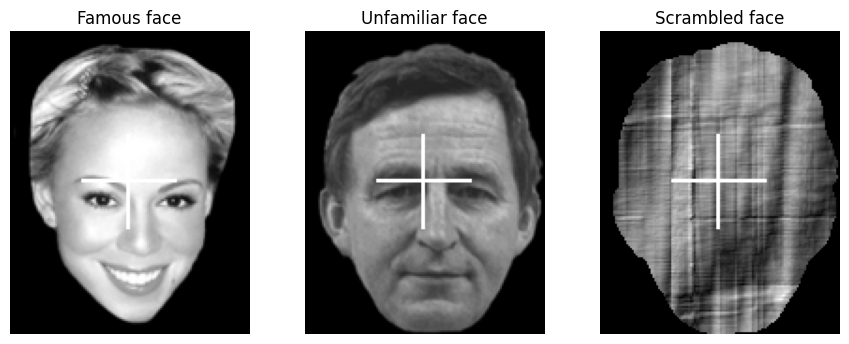

In [6]:
# Packages we will use throughout the notebook
import pandas as pd                 # tabular data (TSV tables, confounds, IQMs)
import matplotlib.pyplot as plt     # static plots
from PIL import Image               # opening .bmp stimulus images

# The dataset ships its task stimuli inside a BIDS-standard `stimuli/` folder.
# For the fMRI sessions the images live under stimuli/func/ and are named
#   f###.bmp   famous face
#   u###.bmp   unfamiliar face
#   s###.bmp   scrambled face
stim_dir = RAW_DIR / 'stimuli' / 'func'

# Pick one example of each category just to show what a participant saw
examples = {
    'Famous face'     : 'f011.bmp',
    'Unfamiliar face' : 'u002.bmp',
    'Scrambled face'  : 's002.bmp',
}

# Small 1-row, 3-column figure with one image per category
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))    # we make a figure with 3 subfigures (columns)
for ax, (label, fname) in zip(axes, examples.items()):  # for each ax
    ax.imshow(Image.open(stim_dir / fname), cmap='gray')   # we plot one image. BMPs are greyscale
    ax.set_title(label); ax.axis('off')                    # hide axes and add titles
plt.tight_layout()
plt.savefig('results/sess-1b/stimuli_examples.png', dpi=120, bbox_inches='tight')
plt.show()


> 📖 For full details of the experimental design, see the original paper:
> Wakeman, D. G., & Henson, R. N. (2015). *A multi-subject, multi-modal human neuroimaging dataset.* Scientific Data, 2, 150001. [nature.com/articles/sdata20151](https://www.nature.com/articles/sdata20151)

### 1.4 📝 Practice: explore the BIDS folder

Before we dive into QC and preprocessing, take a moment to look at the raw dataset with your own eyes. In VS Code's **Explorer** panel on the left, expand:

```
HBI/
└── results/
    └── sess-1b/
        └── ds000117/
```

Browse through the folder. You should recognise everything from sess-1a: top-level files like `participants.tsv`, `dataset_description.json`, `task-facerecognition_bold.json`, and one folder per subject.

> **Questions:**
> 1. Open `participants.tsv`. What columns does it contain, and how many subjects are there?
>
> 2. Open `task-facerecognition_bold.json`. What software was used for DICOM to nifti conversion? What is the TR?
>
> 3. Pick any one subject. Looking at `ses-mri/anat/` and `ses-mri/func/`, can you tell, just from the filenames, which file is the T1w and which are the BOLD runs?
>
> 4. Open the anatomical and one functional images using the Explorer tab on the left. Can you tell what is the matrix size of the two images? Which one has a higher spatial resolution?
>
> 5. Open one of the `sub-XX_ses-mri_task-facerecognition_run-XX_events.tsv` files. What do the columns describe, and what kind of experimental design does it encode?

We will not touch the derivatives (MRIQC, fMRIprep) yet: those come in the next two sections.


## 2. Quality Control with MRIQC

### 2.1 Why QC before anything else?

Before running any preprocessing or statistical analysis, you should **look at your data**. Brain imaging is noisy, and problems that make results meaningless (excessive head motion, signal dropouts, coil failures, wrong coverage, ghosting) are often obvious in the raw images or in a handful of summary metrics. Detecting them early saves hours, or sometimes weeks, of analysis downstream.

For instance, have a look at these images we saw during our lecture on pre-processing:

<img src="assets/sess-1b/figures/lecture-mri-artifacts.png" width="700" style="border: 1.5px solid black;"/>

These images show common issues that we can spot early (and save ourselves quite some time) just by visually inspecting the images before preprocessing.

> **Question**: Can you identify what is the source of the artefacts in the image above?

However, some of the issues are not immediately visible upon visual inspection -- they need to be quantified. This is where **[MRIQC](https://mriqc.readthedocs.io/)** comes in. MRIQC is a BIDS App that takes a BIDS dataset and produces, for each image, a set of **Image Quality Metrics (IQMs)** and an **HTML report** summarising them visually. It does not *modify* the data: it only *characterises* it.

### 2.2 What does MRIQC measure?

MRIQC computes dozens of metrics per image. Some examples:

| Metric | Modality | What it captures | Intuition |
|---|---|---|---|
| **SNR** (signal-to-noise ratio) | T1w, BOLD | signal inside tissue ÷ noise outside the brain | higher = better |
| **tSNR** (temporal SNR) | BOLD | mean ÷ standard deviation across time, per voxel | higher = cleaner time series |
| **FD** (framewise displacement) | BOLD | per-volume head movement in mm | lower = less motion; > 0.5 mm per volume is usually considered a problem |
| **DVARS** | BOLD | RMS change in image intensity between consecutive volumes | spikes indicate sudden signal changes, often motion-related |

You will meet **FD** and **DVARS** again later on: these are key "motion metrics" that connect MRIQC (QC of the *raw* data) with fMRIprep (QC of the *preprocessed* data).

### 2.3 The MRIQC command

MRIQC follows the standard BIDS App interface: `mriqc BIDS_DIR OUTPUT_DIR ANALYSIS_LEVEL [options]`. 

A typical MRIQC call for a single subject looks like this:

```bash
# Participant level: one subject at a time, produces one HTML report per image
mriqc \
/path/to/ds000117 \         # This is your BIDS input folder
/path/to/ds000117-mriqc \   # Output folder
participant \               # Level. Must be participant, group
--participant-label 03 \    # Participant(s) label(s)
--n-procs 4 --mem-gb 16     # Here we set the available resources (4 cpu cores, 16 GB of RAM)
```

And once you have all the participants processed, you can run the group-level call:

```bash
# Group level: aggregates all participants into a group TSV and a group HTML report
mriqc \
/path/to/ds000117 \
/path/to/ds000117-mriqc \
group                       # Same as above, but different level
```

> **Note**: it is good practice to look at the documentation page of the tools you plan on using. For MRIQC, you can find the docs [here](https://mriqc.readthedocs.io/en/latest/usage.html#command-line-interface). 

Two things to notice. First, the **two analysis levels**: `participant` runs the per-image analysis; `group` pools the results into group-level summary TSVs and an HTML group report. You typically run participant-level in parallel on all subjects, then group-level once at the end. Second, `--participant-label` takes the subject ID **without the `sub-` prefix**: a BIDS App convention shared by all BIDS Apps.

On Neurodesk, MRIQC is available directly from the **Applications → Neurodesk → Functional Imaging → mriqc** menu, which opens a terminal with the MRIQC container loaded. You can also load it from any terminal with `ml mriqc/<version>`.

> ⏱️ **Runtime.** MRIQC typically takes ~20 minutes per subject (for our 9 runs). For 16 subjects that is several hours of compute. To save class time, **we will not run MRIQC now**: we copy the pre-computed outputs from the shared course folder and inspect them.

### 2.4 🐍 Get the MRIQC derivatives


In [7]:
# Copy the MRIQC derivatives. Same idempotent pattern as §1.1.
! rm -rf results/sess-1b/ds000117-mriqc
! cp -r /data/shared/sess-1b/ds000117-mriqc results/sess-1b/


rm: cannot remove 'results/sess-1b/ds000117-mriqc/sub-05_ses-mri_task-facerecognition_run-02_bold.html': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-mriqc/README.md': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-mriqc/sub-03/ses-mri/anat/sub-03_ses-mri_acq-mprage_T1w.json': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-mriqc/sub-03/ses-mri/func/sub-03_ses-mri_task-facerecognition_run-02_bold.json': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-mriqc/sub-03/ses-mri/func/sub-03_ses-mri_task-facerecognition_run-01_bold.json': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-mriqc/group_bold.tsv': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-mriqc/group_T1w.tsv': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-mriqc/sub-03_ses-mri_acq-mprage_T1w.html': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-mriqc/sub-03_ses-mri_task-facerecognition_run-01_bold.html': Permiss

cp: cannot create regular file 'results/sess-1b/ds000117-mriqc/sub-05_ses-mri_task-facerecognition_run-02_bold.html': Permission denied
cp: cannot create regular file 'results/sess-1b/ds000117-mriqc/sub-05/ses-mri/func/sub-05_ses-mri_task-facerecognition_run-01_bold.json': Permission denied
cp: cannot create regular file 'results/sess-1b/ds000117-mriqc/sub-05/ses-mri/func/sub-05_ses-mri_task-facerecognition_run-02_bold.json': Permission denied
cp: cannot create regular file 'results/sess-1b/ds000117-mriqc/sub-05/ses-mri/anat/sub-05_ses-mri_acq-mprage_T1w.json': Permission denied


In [8]:
# Tree of the MRIQC derivatives (depth 2 is enough)
! tree -L 2 results/sess-1b/ds000117-mriqc | head -40


results/sess-1b/ds000117-mriqc
├── README.md
├── dataset_description.json
├── group_T1w.tsv
├── group_bold.tsv
├── sub-03
│   └── ses-mri
├── sub-03_ses-mri_acq-mprage_T1w.html
├── sub-03_ses-mri_task-facerecognition_run-01_bold.html
├── sub-03_ses-mri_task-facerecognition_run-02_bold.html
├── sub-05
│   └── ses-mri
├── sub-05_ses-mri_acq-mprage_T1w.html
├── sub-05_ses-mri_task-facerecognition_run-01_bold.html
└── sub-05_ses-mri_task-facerecognition_run-02_bold.html

5 directories, 10 files


Notice the structure:

- At the top level, one **`.html` report per image**: one per T1w, one per BOLD run. These are what you open to look at individual scans.
- Two **group-level tables**: `group_T1w.tsv` and `group_bold.tsv`. Each row is one image, each column is one IQM. These are great for plotting distributions and spotting outliers.
- Per-subject folders containing the raw IQM JSONs and figure data.

### 2.5 🐍 Exploring the group-level IQMs in Python

Let's read `group_bold.tsv` and look at how FD, tSNR, and DVARS are distributed across all subjects and runs.


In [9]:
# The group-level TSVs are tab-separated tables. `sep='\t'` tells pandas
# to parse tabs, not commas. One row per image, one column per IQM.
group_bold = pd.read_csv(MRIQC_DIR / 'group_bold.tsv', sep='\t')
group_T1w  = pd.read_csv(MRIQC_DIR / 'group_T1w.tsv',  sep='\t')

print("BOLD scans across whole dataset (runs * subjects):", len(group_bold))
print("T1w  scans (across all subjects):", len(group_T1w))
print()

# Preview a few columns to build intuition. `bids_name` is the BIDS filename;
# the rest are the IQMs we described in the table above.
print("A few key columns for BOLD:")
print(group_bold[['bids_name', 'fd_mean', 'fd_perc', 'tsnr', 'dvars_nstd']].head())

BOLD scans across whole dataset (runs * subjects): 144
T1w  scans (across all subjects): 16

A few key columns for BOLD:
                                         bids_name   fd_mean    fd_perc  \
0  sub-01_ses-mri_task-facerecognition_run-01_bold  0.069016   0.000000   
1  sub-01_ses-mri_task-facerecognition_run-02_bold  0.105471   9.134615   
2  sub-01_ses-mri_task-facerecognition_run-03_bold  0.117011   9.134615   
3  sub-01_ses-mri_task-facerecognition_run-04_bold  0.115467  13.461538   
4  sub-01_ses-mri_task-facerecognition_run-05_bold  0.109942  11.057692   

        tsnr  dvars_nstd  
0  60.978129   23.993973  
1  52.849417   26.812632  
2  53.264298   27.318733  
3  52.961177   27.987320  
4  48.071203   25.402954  


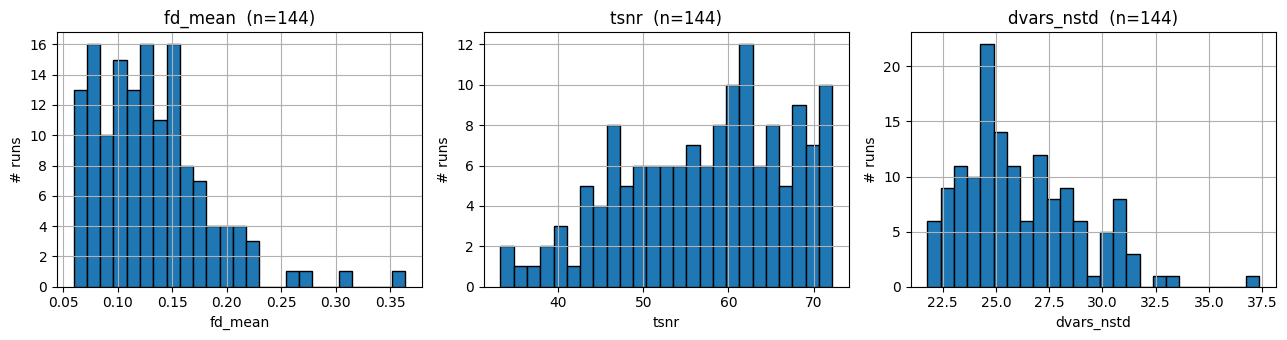

In [12]:
# Plot the histogram of three key IQMs across all BOLD runs in the dataset.
# A long right tail in fd_mean = some runs with noticeably more motion than the rest.
metrics = ['fd_mean', 'tsnr', 'dvars_nstd']
fig, axes = plt.subplots(1, len(metrics), figsize=(13, 3.5))
for ax, metric in zip(axes, metrics):
    # `.hist()` on a pandas Series plots a histogram of its values
    group_bold[metric].hist(bins=25, ax=ax, edgecolor='black')
    ax.set_title(f"{metric}  (n={group_bold[metric].notna().sum()})")   # n = non-missing values
    ax.set_xlabel(metric); ax.set_ylabel('# runs')
plt.tight_layout()
plt.savefig('results/sess-1b/iqm_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


The distribution of `fd_mean` has a clear right tail: most runs sit around 0.1 mm, but a handful are well above 0.2 mm. We can use this to pick a **low-motion subject** ("good") and a **high-motion subject** ("bad") to compare in detail throughout the rest of the notebook.


In [ ]:
# Extract the 2-digit subject id from each BIDS filename using a regex.
# The pattern r'sub-([0-9]+)' captures the digits after 'sub-'.
df = group_bold.copy()
df['sub'] = df['bids_name'].str.extract(r'sub-([0-9]+)')

# Average fd_mean per subject (each subject has 9 runs), then sort ascending.
by_sub = df.groupby('sub')['fd_mean'].mean().sort_values()

print("Subjects ranked by mean FD across all 9 runs:")
print(by_sub.to_string())

# Pick the extremes of the distribution: least and most motion.
GOOD_SUB = by_sub.index[0]    # first row after sort  -> lowest mean FD
BAD_SUB  = by_sub.index[-1]   # last row after sort   -> highest mean FD
print()
print(f"GOOD = sub-{GOOD_SUB}  (mean FD = {by_sub.iloc[0]:.3f} mm)")
print(f"BAD  = sub-{BAD_SUB}  (mean FD = {by_sub.iloc[-1]:.3f} mm)")


Subjects ranked by mean FD across all 9 runs:
sub
05    0.067857
06    0.078924
08    0.089159
02    0.089474
15    0.112338
10    0.118948
13    0.119195
14    0.122002
11    0.123384
01    0.131644
16    0.141540
04    0.160024
07    0.164374
12    0.178825
09    0.184362
03    0.201626

GOOD = sub-05  (mean FD = 0.068 mm)
BAD  = sub-03  (mean FD = 0.202 mm)


These two subjects are our reference pair for the rest of the notebook.

### 2.6 🖥️ Reading an MRIQC HTML report

MRIQC's most important output is the **per-image HTML report**. Each bundles the IQMs with embedded visualisations (background mosaics, carpet plots, tiled slice views) that let you *see* what the numbers describe.

**Instructions:**

1. Switch to **Neurodesktop**.
2. Open the file manager and navigate to `~/HBI/results/sess-1b/ds000117-mriqc/`.
3. Double-click `sub-05_ses-mri_task-facerecognition_run-01_bold.html` to open the **good** subject's report in the browser.
4. Then open `sub-03_ses-mri_task-facerecognition_run-01_bold.html` and compare.

Focus on these panels (more detail in the [MRIQC report docs](https://mriqc.readthedocs.io/en/latest/reports.html)):

- **Background mosaic**: a brightness-boosted view of the air around the head. In a clean scan it looks like uniform noise. Structured patterns here mean ghosting, spikes, or coil problems.
- **Zoomed-in mosaic**: a tiled view of all slices of the brain. Look for dropouts or wraps.
- **Carpet plot**: a 2D representation where each row is one voxel's time series. Vertical stripes = abrupt changes across the whole brain, a hallmark of motion.
- **IQMs table**: the numerical summary at the bottom.

### 2.7 📝 Practice: spot the difference

Open both HTML reports side by side (or in two browser tabs) and answer the questions below.

> **Questions:**
> 1. Which subject has the higher mean FD? By roughly what factor?
>
> 2. Compare the two **carpet plots**. What is structurally different between them?
>
> 3. Looking at the **background mosaic**, do you see any structured patterns in either subject? What would such patterns indicate?
>
> 4. Open the `group_bold.html` report (the group-level one at the top of the folder). Can you spot our two subjects in the group-level scatter plots? Where do they sit compared to the rest of the cohort?


## 3. Preprocessing with fMRIprep

Now that we know the quality of our raw data, we can preprocess it. Preprocessing turns the raw BOLD time series (a 4D volume of intensities, misaligned across time and distorted by several acquisition artefacts) into a **clean, analysis-ready time series** in a standard coordinate space.

### 3.1 What does fMRI preprocessing do?

A typical fMRI preprocessing pipeline performs, in sequence:

1. **Slice-timing correction**: the slices of a single volume are not acquired simultaneously but interleaved over the TR. Slice-timing correction temporally aligns them.
2. **Motion correction (realignment)**: the subject's head moves during scanning. Each volume is rigidly registered (6 parameters: 3 translations + 3 rotations) to a reference volume so the brain is in the same position across time. This is where the **6 Head Motion Parameters (6 HMP)** come from.
3. **Susceptibility distortion correction (SDC)**: BOLD images (echo-planar imaging) are geometrically distorted near air-tissue interfaces (frontal lobes, temporal poles). Fieldmaps, or synthetic fieldmap estimation, are used to undistort them.
4. **Coregistration to T1w**: the BOLD is rigidly aligned to the subject's own T1w anatomical.
5. **Normalisation to a template**: the T1w (and, via the BOLD-to-T1w mapping, the BOLD) is nonlinearly warped to a standard template (typically `MNI152NLin2009cAsym`) so analyses can be pooled across subjects.
6. **Resampling**: after computing all the above transforms, the BOLD is *resampled* to the target grid. For efficiency fMRIprep composes all the transforms and applies a **single resampling**, which limits blurring from repeated interpolation.
7. **Confound estimation**: fMRIprep does not clean the signal itself (that is your decision at the analysis stage), but it computes a large set of **nuisance regressors** (motion, aCompCor, CSF/WM signals, FD, DVARS, ...) and writes them to a `*_desc-confounds_timeseries.tsv` file for you to use downstream.

> The terms **realignment** (step 2) and **resampling** (step 6) are worth distinguishing. *Realignment* computes the motion transforms; *resampling* applies them (together with the coregistration and normalisation transforms) to the voxel grid.

### 3.2 Why fMRIprep?

Before fMRIprep, each lab typically assembled its own preprocessing pipeline from FSL/SPM/ANTs/AFNI tools, configured differently across labs and projects: a major source of variability across papers. **[fMRIprep](https://fmriprep.org/)** was designed as an **opinionated, minimally-configurable pipeline** that exposes only a handful of scientific decisions to the user and handles the hundreds of implementation details uniformly. It is BIDS-native (input *and* output), is packaged as a container, is publicly maintained, and has been validated by thousands of studies.

### 3.3 The fMRIprep command

Here is a typical fMRIprep command:

```bash
fmriprep \
    /path/to/ds000117 \
    /path/to/ds000117-fmriprep \
    participant \
    --participant-label 03 \
    --output-spaces MNI152NLin2009cAsym:res-2 T1w \
    --fs-license-file /path/to/freesurfer.lic \
    --fs-no-reconall \
    --n-procs 8 --mem-mb 32000 \
    -w /scratch/fmriprep-work
```

Key options:

- `--output-spaces`: the target spaces into which the BOLD is resampled. `MNI152NLin2009cAsym:res-2` means the standard 2 mm MNI template; `T1w` keeps a copy in the subject's native anatomical space.
- `--fs-license-file`: FreeSurfer is used for anatomical segmentation; it requires a (free) license file.
- `--fs-no-reconall`: skip the multi-hour FreeSurfer surface reconstruction. Fast, but no surface outputs. **We will use this flag in the home exercise** to keep runtime reasonable.
- `-w` / `--work-dir`: scratch directory for intermediate files (can be several GB per subject).

> ⏱️ **Runtime.** fMRIprep typically takes **several hours per subject** with `--fs-no-reconall`, and close to a day with full FreeSurfer reconstruction. Memory usage is in the 10-30 GB range. **We will not run fMRIprep now**: we copy the pre-computed outputs.

### 3.4 🐍 Get the fMRIprep derivatives


In [ ]:
# Copy the fMRIprep derivatives. Same idempotent pattern as §1.1.
# Larger than MRIQC: per-subject it includes the preprocessed BOLD, transforms,
# anatomical derivatives, and the HTML report with its SVG figures.
! rm -rf results/sess-1b/ds000117-fmriprep
! cp -r /data/shared/sess-1b/ds000117-fmriprep results/sess-1b/


rm: cannot remove 'results/sess-1b/ds000117-fmriprep/desc-aseg_dseg.tsv': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-fmriprep/README.md': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-fmriprep/sub-03/ses-mri/anat/sub-03_ses-mri_acq-mprage_space-MNI152NLin2009cAsym_res-2_dseg.nii.gz': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-fmriprep/sub-03/ses-mri/anat/sub-03_ses-mri_acq-mprage_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-fmriprep/sub-03/ses-mri/anat/sub-03_ses-mri_acq-mprage_label-CSF_probseg.nii.gz': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-fmriprep/sub-03/ses-mri/anat/sub-03_ses-mri_acq-mprage_from-fsnative_to-T1w_mode-image_xfm.txt': Permission denied
rm: cannot remove 'results/sess-1b/ds000117-fmriprep/sub-03/ses-mri/anat/sub-03_ses-mri_acq-mprage_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz': Permission denied
rm: cannot

In [ ]:
# Tree of the fMRIprep derivatives for one subject — all runs, all outputs
! tree -L 4 results/sess-1b/ds000117-fmriprep/sub-03 | head -40


results/sess-1b/ds000117-fmriprep/sub-03
├── figures
│   ├── sub-03_ses-mri_acq-mprage_desc-conform_T1w.html
│   ├── sub-03_ses-mri_acq-mprage_desc-reconall_T1w.svg
│   ├── sub-03_ses-mri_acq-mprage_dseg.svg
│   ├── sub-03_ses-mri_acq-mprage_space-MNI152NLin2009cAsym_T1w.svg
│   ├── sub-03_ses-mri_acq-mprage_space-MNI152NLin6Asym_T1w.svg
│   ├── sub-03_ses-mri_desc-about_T1w.html
│   ├── sub-03_ses-mri_desc-summary_T1w.html
│   ├── sub-03_ses-mri_fmapid-auto00000_desc-phasediff_fieldmap.svg
│   ├── sub-03_ses-mri_task-facerecognition_run-1_desc-aroma_bold.svg
│   ├── sub-03_ses-mri_task-facerecognition_run-1_desc-bbregister_bold.svg
│   ├── sub-03_ses-mri_task-facerecognition_run-1_desc-carpetplot_bold.svg
│   ├── sub-03_ses-mri_task-facerecognition_run-1_desc-compcorvar_bold.svg
│   ├── sub-03_ses-mri_task-facerecognition_run-1_desc-confoundcorr_bold.svg
│   ├── sub-03_ses-mri_task-facerecognition_run-1_desc-rois_bold.svg
│   ├── sub-03_ses-mri_task-facerecognition_run-1_desc-sdc_bold

The per-subject structure follows BIDS-Derivatives:

- `anat/`: preprocessed T1w, brain mask, tissue probability maps, transforms to MNI.
- `func/`: preprocessed BOLD in each output space, brain masks, and **the confounds TSV** (`*_desc-confounds_timeseries.tsv`), one per BOLD run.
- `figures/`: the per-subject SVG figures embedded in the HTML report.

> **Note on filenames.** The raw data uses two-digit run numbers (`run-01`, `run-02`, ...) but fMRIprep rewrites them with single digits (`run-1`, `run-2`, ...). This is a small BIDS inconsistency to keep in mind when writing globs.

To keep the shared folder small, we have pre-staged only **runs 1 and 2** of the preprocessed BOLD for each subject. The confounds and motion traces for those two runs are more than enough for our teaching purposes.

### 3.5 🐍 Loading the preprocessed BOLD

Let's load the preprocessed BOLD for the good subject in MNI space and do the same kind of inspection we did in sess-1a.


In [ ]:
import nibabel as nib                     # loads NIfTI files (sess-1a)
from nilearn import plotting, image         # plots + image ops on brain volumes
from bids import BIDSLayout                 # query BIDS datasets by entity (sess-1a)

# Build a BIDSLayout over both the raw dataset AND its fMRIprep derivatives.
# Passing `derivatives=FMRIPREP_DIR` tells pybids to also index the preprocessed
# outputs under their BIDS-Derivatives entities (space, res, desc, ...).
layout = BIDSLayout(RAW_DIR, derivatives=str(FMRIPREP_DIR))
print(layout)


BIDS Layout: ...n/HBI/results/sess-1b/ds000117 | Subjects: 2 | Sessions: 2 | Runs: 4


In [ ]:
# Ask the layout for the preprocessed BOLD of our two subjects (run-1, MNI @ 2 mm).
# `return_type='filename'` gives us the file path as a string; `extension='.nii.gz'`
# rules out the accompanying JSON sidecar.
def preproc_bold(sub, run=1, space='MNI152NLin2009cAsym', res=2):
    hits = layout.get(subject=sub, run=run, space=space, res=res,
                      desc='preproc', suffix='bold', extension='.nii.gz',
                      return_type='filename')
    return hits[0] if hits else None

good_bold = preproc_bold(GOOD_SUB)
bad_bold  = preproc_bold(BAD_SUB)
print('good:', good_bold)
print('bad :', bad_bold)

# Peek at the NIfTI header, same fields we inspected in sess-1a
img = nib.load(good_bold)
print('shape   :', img.shape)              # (X, Y, Z, T); T = number of volumes
print('voxel mm:', img.header.get_zooms()) # (x, y, z, TR) — note TR is the 4th value
print('TR (s)  :', img.header.get_zooms()[3])


good: /home/jovyan/HBI/results/sess-1b/ds000117-fmriprep/sub-05/ses-mri/func/sub-05_ses-mri_task-facerecognition_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
bad : /home/jovyan/HBI/results/sess-1b/ds000117-fmriprep/sub-03/ses-mri/func/sub-03_ses-mri_task-facerecognition_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz
shape   : (97, 115, 97, 208)
voxel mm: (np.float32(2.0), np.float32(2.0), np.float32(2.0), np.float32(2.0))
TR (s)  : 2.0


In [ ]:
# Average the 4D time series across time, giving a single 3D volume.
# For a preprocessed BOLD this should look like a grey-matter-highlighted EPI
# in the target MNI template — good sanity check that we are in the right space.
mean_good = image.mean_img(good_bold, copy_header=True)
plotting.plot_epi(mean_good, title=f'sub-{GOOD_SUB} - mean preprocessed BOLD (MNI)',
                  display_mode='ortho',           # axial/coronal/sagittal panels
                  cut_coords=(0, -10, 18))        # slice positions in MNI mm
plotting.show()


KeyboardInterrupt: 

### 3.6 🐍 Head Motion Parameters (6 HMP)

The confounds TSV is where fMRIprep writes all its nuisance regressors. It is a tab-separated file with **one row per volume** and many columns, including the six motion parameters (`trans_x/y/z`, `rot_x/y/z`), `framewise_displacement`, `dvars`, aCompCor components, CSF and WM signals, and a `motion_outlier_*` column for each high-motion volume.

Let's load the confounds and plot the **6 HMP** for both subjects side by side.


In [ ]:
# Use pybids to locate the confounds TSV and pandas to read it.
# `desc='confounds'` + `suffix='timeseries'` + `extension='.tsv'` uniquely
# identifies the confounds file for a given subject/run.
def confounds(sub, run=1):
    hits = layout.get(subject=sub, run=run,
                      desc='confounds', suffix='timeseries', extension='.tsv',
                      return_type='filename')
    return pd.read_csv(hits[0], sep='\t') if hits else None

# Load confounds for both subjects so we can compare them
cg = confounds(GOOD_SUB)
cb = confounds(BAD_SUB)
print('good confounds: shape =', cg.shape)           # (n_volumes, n_regressors)
print('first columns :', list(cg.columns)[:15])


good confounds: shape = (208, 250)
first columns : ['global_signal', 'global_signal_derivative1', 'global_signal_derivative1_power2', 'global_signal_power2', 'csf', 'csf_derivative1', 'csf_power2', 'csf_derivative1_power2', 'white_matter', 'white_matter_derivative1', 'white_matter_derivative1_power2', 'white_matter_power2', 'csf_wm', 'tcompcor', 'std_dvars']


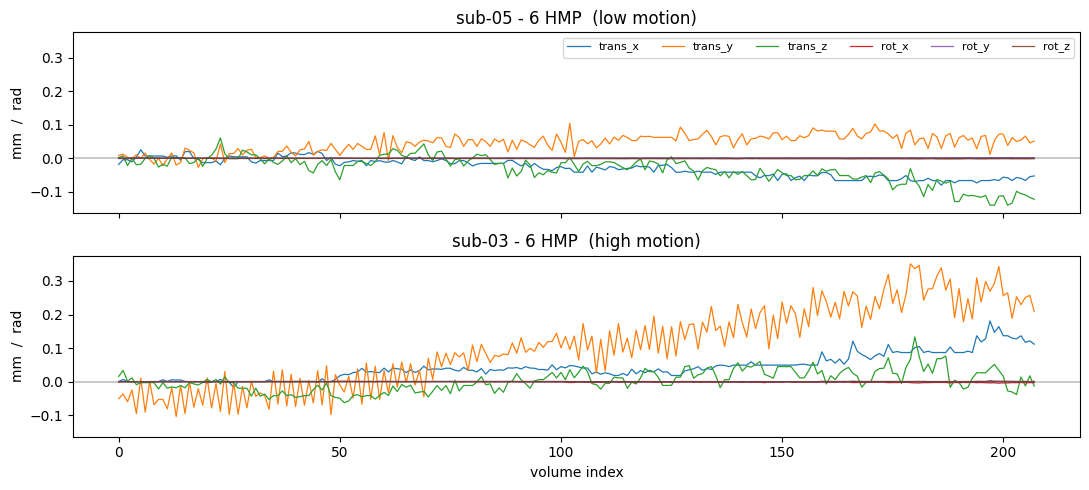

In [ ]:
# The six head motion parameters written by fMRIprep.
# Translations are in mm, rotations in radians (both relative to the reference volume).
HMP = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

# Two stacked subplots: top = good subject, bottom = bad subject
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True, sharey=True)
for ax, df, sub, tag in zip(axes, [cg, cb], [GOOD_SUB, BAD_SUB], ['low motion', 'high motion']):
    for col in HMP:
        ax.plot(df[col], label=col, linewidth=0.9)   # one line per parameter
    ax.set_title(f'sub-{sub} - 6 HMP  ({tag})')
    ax.set_ylabel('mm  /  rad')
    ax.axhline(0, color='k', linewidth=0.3)          # reference line at 0
axes[-1].set_xlabel('volume index')                  # volumes, not seconds
axes[0].legend(ncol=6, fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('results/sess-1b/hmp_good_vs_bad.png', dpi=120, bbox_inches='tight')
plt.show()


The bad subject's motion parameters show larger, more abrupt jumps than the good subject's. These six traces are exactly what fMRIprep used during the **realignment** step to rigidly re-register each volume to a reference; they are also the columns you typically include (or a subset, or their derivatives) as **nuisance regressors** in a first-level GLM to remove residual motion-related signal.

### 3.7 🐍 FD and DVARS

**Framewise Displacement (FD)** summarises the 6 motion parameters into a single per-volume scalar: how much (in mm) the head moved between this volume and the previous one, combining translations and rotations. **DVARS** measures how much the *whole-brain signal* changed from one volume to the next. Spikes in both usually co-occur.

A commonly used threshold for "problematic" volumes is **FD > 0.5 mm**.


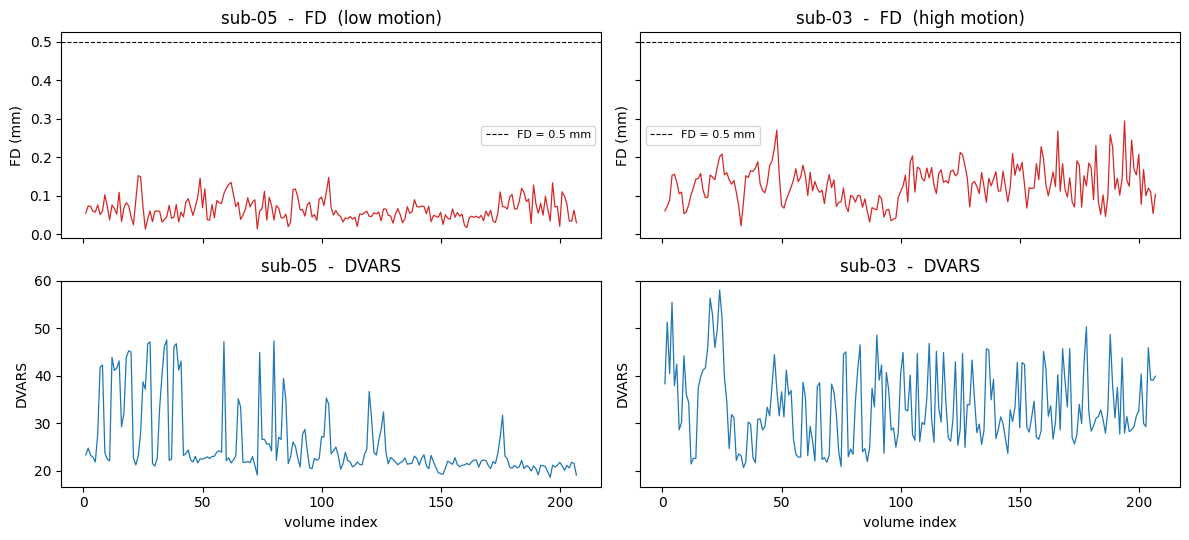

sub-05: 0/208 volumes with FD > 0.5 mm (0.0%)
sub-03: 0/208 volumes with FD > 0.5 mm (0.0%)


In [ ]:
# 2x2 grid: rows = metric (FD, DVARS), columns = subject (good, bad)
fig, axes = plt.subplots(2, 2, figsize=(12, 5.5), sharex='col', sharey='row')
for col, (df, sub, tag) in enumerate(zip([cg, cb], [GOOD_SUB, BAD_SUB], ['low motion', 'high motion'])):
    # Top row: FD time course, with the 0.5 mm problematic-volume threshold drawn in
    axes[0, col].plot(df['framewise_displacement'], color='C3', linewidth=0.9)
    axes[0, col].axhline(0.5, color='k', linestyle='--', linewidth=0.8, label='FD = 0.5 mm')
    axes[0, col].set_title(f'sub-{sub}  -  FD  ({tag})')
    axes[0, col].set_ylabel('FD (mm)'); axes[0, col].legend(fontsize=8)

    # Bottom row: DVARS time course
    axes[1, col].plot(df['dvars'], color='C0', linewidth=0.9)
    axes[1, col].set_title(f'sub-{sub}  -  DVARS')
    axes[1, col].set_ylabel('DVARS'); axes[1, col].set_xlabel('volume index')

plt.tight_layout()
plt.savefig('results/sess-1b/fd_dvars_good_vs_bad.png', dpi=120, bbox_inches='tight')
plt.show()

# Print how many volumes would be censored if we applied the 0.5 mm FD threshold
for df, sub in zip([cg, cb], [GOOD_SUB, BAD_SUB]):
    n   = int((df['framewise_displacement'] > 0.5).sum())
    tot = len(df)
    print(f"sub-{sub}: {n}/{tot} volumes with FD > 0.5 mm ({100*n/tot:.1f}%)")


If you were running a GLM on this data, you would typically **censor** (remove, or regress out with one-hot columns) the high-FD volumes, using the `motion_outlier_*` columns fMRIprep already computed for you in the confounds TSV.

### 3.8 🖥️ Reading the fMRIprep HTML report (post-preprocessing QC)

fMRIprep also produces a **per-subject HTML report** that is the post-preprocessing QC. Unlike MRIQC (which only describes the raw data), this report shows you **what fMRIprep actually did** to the data, and lets you verify each step visually. Almost every panel is an interactive SVG: hovering with the mouse fades between the *before* and *after* images.

Below are a few of the key panels, taken directly from our good subject's fMRIprep output. Open the full report in Neurodesktop to see them interactively.

**Anatomical tissue segmentation.** fMRIprep segments the T1w into grey matter, white matter, and CSF. The coloured contours should hug the correct anatomical boundaries:

<img src="results/sess-1b/ds000117-fmriprep/sub-05/figures/sub-05_ses-mri_acq-mprage_dseg.svg" width="900" style="border: 1.5px solid black;"/>

**Spatial normalisation to MNI.** The T1w is nonlinearly warped to the `MNI152NLin2009cAsym` template. The red contour is the template boundary; it should closely follow the brain edge:

<img src="results/sess-1b/ds000117-fmriprep/sub-05/figures/sub-05_ses-mri_acq-mprage_space-MNI152NLin2009cAsym_T1w.svg" width="900" style="border: 1.5px solid black;"/>

**BOLD-to-T1w coregistration (BBR).** The BOLD reference image is rigidly aligned to the subject's own T1w. Boundaries (grey-white) should line up between the two modalities:

<img src="results/sess-1b/ds000117-fmriprep/sub-05/figures/sub-05_ses-mri_task-facerecognition_run-1_desc-bbregister_bold.svg" width="900" style="border: 1.5px solid black;"/>

**Susceptibility distortion correction (SDC).** Before/after EPI distortion correction. The *after* image should look anatomically closer to the T1w, especially in frontal and temporal regions:

<img src="results/sess-1b/ds000117-fmriprep/sub-05/figures/sub-05_ses-mri_task-facerecognition_run-1_desc-sdc_bold.svg" width="900" style="border: 1.5px solid black;"/>

**Carpet plot of the preprocessed BOLD.** The same visualisation we saw in MRIQC, but now on *preprocessed* data. Vertical stripes associated with head motion should be largely gone:

<img src="results/sess-1b/ds000117-fmriprep/sub-05/figures/sub-05_ses-mri_task-facerecognition_run-1_desc-carpetplot_bold.svg" width="900" style="border: 1.5px solid black;"/>

**Instructions to open the full report yourself:**

1. Switch to **Neurodesktop**.
2. Open `~/HBI/results/sess-1b/ds000117-fmriprep/sub-05.html` in the browser.
3. Scroll through each panel, hovering over the SVGs to see before/after overlays.
4. Then open `sub-03.html` and compare. The bad subject's report often looks subtly different in the BOLD-related panels (coregistration, SDC, carpet), because motion during acquisition affects every downstream step.

### 3.9 🐍 Before vs after: the carpet plot

The carpet plot above shows preprocessed data. For completeness, let's also compute it for the **raw** BOLD of our bad subject and compare the two side by side.


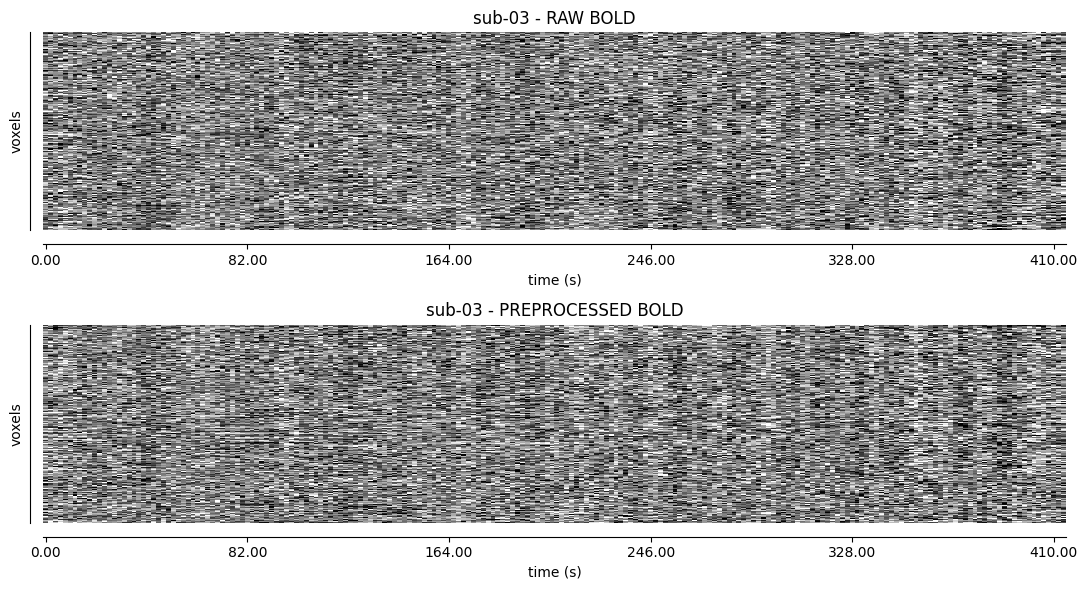

In [ ]:
from nilearn.plotting import plot_carpet

# Raw BOLD for the bad subject (run-1, no `desc` entity)
raw_bold = layout.get(subject=BAD_SUB, run=1, suffix='bold', extension='.nii.gz',
                      desc=None, space=None, return_type='filename')[0]

# Preprocessed BOLD: same call we already used above
pre_bold = preproc_bold(BAD_SUB)

# Brain mask (MNI, 2 mm) produced by fMRIprep - restricts the carpet plot to
# in-brain voxels, which makes the visualisation much cleaner.
mask = layout.get(subject=BAD_SUB, run=1, space='MNI152NLin2009cAsym', res=2,
                  desc='brain', suffix='mask', extension='.nii.gz',
                  return_type='filename')[0]

# Two carpet plots stacked vertically: raw (top) vs preprocessed (bottom)
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
plot_carpet(raw_bold, axes=axes[0],
            title=f'sub-{BAD_SUB} - RAW BOLD', standardize='zscore_sample')
plot_carpet(pre_bold, mask_img=mask, axes=axes[1],
            title=f'sub-{BAD_SUB} - PREPROCESSED BOLD', standardize='zscore_sample')
plt.tight_layout()
plt.savefig('results/sess-1b/carpet_before_after.png', dpi=120, bbox_inches='tight')
plt.show()


The bright/dark vertical bands of the raw carpet, each corresponding to a moment when the head moved, are largely gone after realignment + resampling + normalisation. Residual stripes at high-FD volumes are exactly what the `motion_outlier_*` columns of the confounds TSV will help you censor in the GLM.


## 📝 Exercises

Now it is your turn. Using what you have learned about MRIQC and fMRIprep, complete the exercises below. These are **homework**: fMRIprep is too slow to run in class, so you will run it yourself on Neurodesk at home.

---

**Exercise 1: pick a new subject**

a. Pick **one subject** from `ds000117` other than `sub-03` and `sub-05` (the ones we used above).

b. Open the MRIQC group-level report at `results/sess-1b/ds000117-mriqc/group_bold.html` and note where your subject sits in the distribution of `fd_mean` and `tsnr`. Is it a low-motion or a high-motion subject?

c. Open the MRIQC per-run HTML report for *one* of your subject's BOLD runs. Write 2-3 sentences describing what you see (IQMs, carpet plot, background).

---

**Exercise 2: run fMRIprep at home**

Now run fMRIprep yourself on the subject you just picked, on one or two BOLD runs.

a. Open **Neurodesktop**, open a terminal, and use DataLad to fetch the raw data for your subject:

```bash
cd ~/HBI/results/sess-1b
datalad install -s ///openneuro/ds000117 ds000117-mine
datalad get -d ds000117-mine \
    ds000117-mine/sub-10/ses-mri/anat \
    ds000117-mine/sub-10/ses-mri/func/*run-01* \
    ds000117-mine/sub-10/ses-mri/func/*run-02*
```

Replace `10` with the subject you picked.

b. Load fMRIprep and run it with `--fs-no-reconall` to keep runtime manageable (~1-2 hours):

```bash
ml fmriprep/<version>

fmriprep \
    ~/HBI/results/sess-1b/ds000117-mine \
    ~/HBI/results/sess-1b/ds000117-fmriprep-mine \
    participant \
    --participant-label 10 \
    --output-spaces MNI152NLin2009cAsym:res-2 \
    --fs-license-file ~/freesurfer.lic \
    --fs-no-reconall \
    --n-procs 4 --mem-mb 16000 \
    -w /tmp/fmriprep-work
```

c. When it finishes, open the HTML report at `~/HBI/results/sess-1b/ds000117-fmriprep-mine/sub-10.html` in the browser. Compare it with the reports of `sub-03` and `sub-05` you already know.

---

**Exercise 3: write a short QC judgement**

Using the fMRIprep HTML report (and, if helpful, the MRIQC report from Exercise 1), write a short QC judgement for your subject (3-5 sentences). Address at least:

a. How much did the subject move? What is the mean FD, and how many volumes are above the 0.5 mm threshold?

b. Does the coregistration between BOLD and T1w look reasonable?

c. Does the normalisation to MNI look reasonable?

d. Based on all of the above, would you include this subject in a group analysis? Why or why not?

> **Troubleshooting tips:**
> - **FreeSurfer license**: even with `--fs-no-reconall`, fMRIprep requires the license file to be present. Request one for free at [surfer.nmr.mgh.harvard.edu/fswiki/License](https://surfer.nmr.mgh.harvard.edu/fswiki/License).
> - **Disk space**: budget ~5-10 GB in the work directory per subject; you can delete the work directory after fMRIprep finishes.
> - **BIDS validator warnings**: warnings (yellow) are fine; errors (red) must be fixed before fMRIprep will run.
> - **Memory errors**: reduce `--n-procs` and `--mem-mb`, or pick a shorter subset of runs.

---

**End of Session 1b.** In the next session we will move from preprocessed BOLD to first-level statistical analysis, using the same ds000117 dataset.
